# Final Python Notebook 2

**Author:** Kalana Malhara




##Library imports

**Code Reuse Session 2 - Seminnar Session 1, 2, 3 and 4**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Classification algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Model selection & evaluation
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay
)

# Preprocessing
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

## Load the classification dataset

**Code Reuse Session 1 - Seminnar Session 1**

In [2]:
#Load the prepared classification dataset from Notebook 1
df_Classification = pd.read_csv('/content/drive/MyDrive/CW/classification_dataset.csv')
df_Classification.head()

,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status
0,21.0,12000,2,0,1,15000,6.99,0.12,0,4,0
1,21.0,13200,2,2,1,25000,16.77,0.19,1,3,0
2,23.0,9600,3,5,3,30000,12.42,0.31,0,3,0
3,40.0,182004,3,3,1,35000,8.00,0.19,0,11,0
4,40.0,90000,0,3,2,35000,12.42,0.39,0,14,0


**Code Reuse Session 1 - Seminnar Session 1**

In [3]:
df_Classification.describe()

,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status
count,58623.000000,5.862300e+04,58623.000000,58623.000000,58623.000000,58623.000000,58623.000000,58623.000000,58623.000000,58623.000000,58623.000000
mean,27.548590,6.404694e+04,1.673643,4.696843,2.519421,9217.244972,10.677761,0.159233,0.148372,5.813418,0.142367
std,6.020502,3.793096e+04,1.452535,3.898871,1.722905,5563.639061,3.034699,0.091696,0.355471,4.029740,0.349429
min,20.000000,4.200000e+03,0.000000,0.000000,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000,0.000000
25%,23.000000,4.200000e+04,0.000000,2.000000,1.000000,5000.000000,7.880000,0.090000,0.000000,3.000000,0.000000
50%,26.000000,5.800000e+04,3.000000,4.000000,3.000000,8000.000000,10.750000,0.140000,0.000000,4.000000,0.000000
75%,30.000000,7.560000e+04,3.000000,7.000000,4.000000,12000.000000,12.990000,0.210000,0.000000,8.000000,0.000000
max,84.000000,1.900000e+06,3.000000,41.000000,5.000000,35000.000000,23.220000,0.830000,1.000000,30.000000,1.000000


**Code Reuse Session 1 - Seminnar Session 1**

In [4]:
#Variables in classification dataset
df_Classification.columns

Index(['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent',
       'loan_amount', 'loan_interest_rate', 'loan_income_ratio',
       'payment_default_on_file', 'credit_history_length',
       'loan_approval_status'],
      dtype='object')

**Code Reuse Session 1 - Seminnar Session 1**

In [5]:
#Classification dataset shape
df_Classification.shape

(58623, 11)

---
# Case Study A: Predicting Loan Approval Status

## Task (4a) – Algorithm Types, Learnable Parameters & Hyperparameters

## Algorithms Comparison


| Algorithm | Type | Learnable Parameters | Hyperparameters |
|----------|------|----------------------|-----------------|
| Naive Bayes | Parametric | Class priors; means & variances | `var_smoothing` |
| Logistic Regression | Parametric | Bias; feature weights | `C`, `penalty`, `max_iter` |
| KNN | Non-parametric | None | `n_neighbors`, `metric`, `weights` |

## Task (4b) – Training-Test Split

**Code Reuse Session 2 - Seminnar Session 1**

In [6]:
#separate input features and target variable
#input variables
X = df_Classification.drop(columns=['loan_approval_status'])
#target variable
y = df_Classification['loan_approval_status']

print("Input Features :")
print(X.columns.tolist())
print("Input Shape:", X.shape)

Input Features :
['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length']
Input Shape: (58623, 10)


**Code Reuse Session 2 - Seminnar Session 3**

In [7]:
#Split the data using train_test_split
#stratify=y - to get the same balance in train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (46898, 10)
X_test shape: (11725, 10)


In [8]:
#Checking the class proportion same in train and test
print("Training set class distribution :")
print(y_train.value_counts(normalize=True).round(2))
print()
print("Test set class distribution :")
print(y_test.value_counts(normalize=True).round(2))

Training set class distribution :
loan_approval_status
0    0.86
1    0.14
Name: proportion, dtype: float64

Test set class distribution :
loan_approval_status
0    0.86
1    0.14
Name: proportion, dtype: float64


## Feature Scaling

**Code Reuse Session 1 - Seminnar Session 2**

In [9]:
#Fit the scaler on training data to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) #keeps the test data completely unseen during training
X_test_scaled  = scaler.transform(X_test) #only applied transformation


---
## Task (5a) – Build & Evaluate the Three Classification Models

### Naive Bayes (NB)

**Code Reuse Session 2 - Seminnar Session 4**

In [10]:
#Declare and fit Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

#Predict the test test
naive_bayes_pred = nb_model.predict(X_test_scaled)


**Code Reuse Session 2 - Seminnar Session 4**

In [11]:
#Classification report– NB
print("Classification report for Naive Bayes: \n")
print(classification_report(y_test, naive_bayes_pred, target_names=['Approved (0)', 'Disapproved (1)']))

Classification report for Naive Bayes: 

                 precision    recall  f1-score   support

   Approved (0)       0.93      0.88      0.91     10056
Disapproved (1)       0.46      0.60      0.52      1669

       accuracy                           0.84     11725
      macro avg       0.69      0.74      0.71     11725
   weighted avg       0.86      0.84      0.85     11725



**Code Reuse Session 2 - Seminnar Session 4**

Confusion Matrix for Naive Bayes:


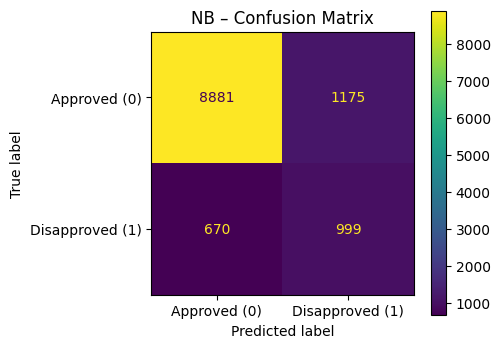

In [12]:
#Confution Matrix - NB
print("Confusion Matrix for Naive Bayes:")
cm_nb = confusion_matrix(y_test, naive_bayes_pred)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=['Approved (0)', 'Disapproved (1)'])
fig, ax = plt.subplots(figsize=(5, 4))
disp_nb.plot(ax=ax)
ax.set_title('NB – Confusion Matrix')
plt.tight_layout()
plt.show()

**Code Reuse Session 2 - Seminnar Session 4**


ROC Curve for Naive Bayes:
NB AUC-ROC: 0.8476


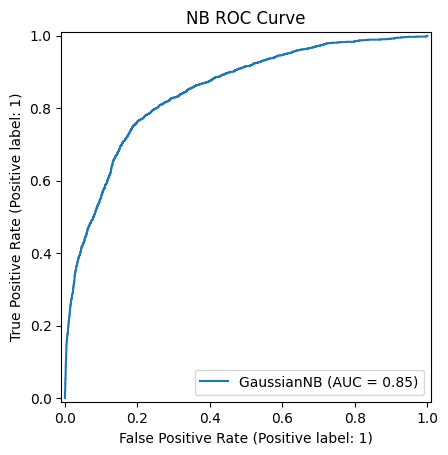

In [13]:
# Calculate probabilities and AUC for Naive Bayes
nb_prob = nb_model.predict_proba(X_test_scaled)[:, 1]
nb_auc = roc_auc_score(y_test, nb_prob)

#AUC-ROC curve – NB
print("\nROC Curve for Naive Bayes:")
print(f"NB AUC-ROC: {nb_auc:.4f}")

# Plot ROC curve using RocCurveDisplay
RocCurveDisplay.from_estimator(nb_model, X_test_scaled, y_test)
plt.title('NB ROC Curve')
plt.show()

### Logistic Regression (LR)

**Code Reuse Session 2 - Seminnar Session 3**

In [14]:
#Declare and fit the LR
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

#Predict the test set
lr_pred = lr_model.predict(X_test_scaled)

**Code Reuse Session 2 - Seminnar Session 3**

In [15]:
#Classification report – LR
print("Classification report for Logistic Regression:\n")
print(classification_report(y_test, lr_pred, target_names=['Approved (0)', 'Disapproved (1)']))

Classification report for Logistic Regression:

                 precision    recall  f1-score   support

   Approved (0)       0.91      0.97      0.94     10056
Disapproved (1)       0.70      0.39      0.50      1669

       accuracy                           0.89     11725
      macro avg       0.80      0.68      0.72     11725
   weighted avg       0.88      0.89      0.87     11725



**Code Reuse Session 2 - Seminnar Session 3**

Confusion Matrix for Logistic Regression:


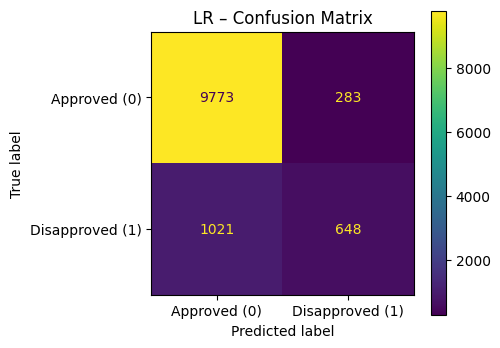

In [16]:
#Confusion matrix – LR
print("Confusion Matrix for Logistic Regression:")
cm_lr = confusion_matrix(y_test, lr_pred)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Approved (0)', 'Disapproved (1)'])
fig, ax = plt.subplots(figsize=(5, 4))
disp_lr.plot(ax=ax)
ax.set_title('LR – Confusion Matrix')
plt.tight_layout()
plt.show()

**Code Reuse Session 2 - Seminnar Session 3**


ROC Curve for Logistic Regression:


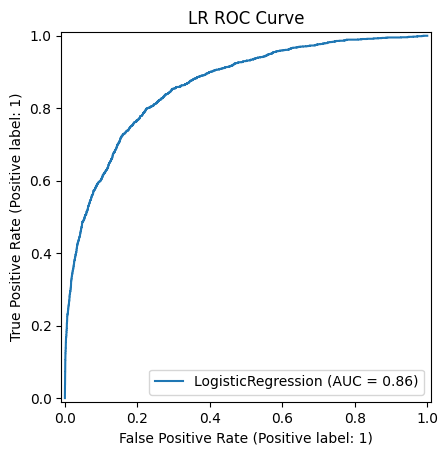

In [17]:
# Calculate probabilities and AUC for Logistic Regression
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_auc = roc_auc_score(y_test, lr_prob)

#AUC-ROC curve – LR
print("\nROC Curve for Logistic Regression:")

# Plot ROC curve using RocCurveDisplay
RocCurveDisplay.from_estimator(lr_model, X_test_scaled, y_test)
plt.title('LR ROC Curve')
plt.show()

**Code Reuse Session 2 - Seminnar Session 4**

In [18]:
#Declare and fit KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

#Predict the test set
knn_pred = knn_model.predict(X_test_scaled)


**Code Reuse Session 2 - Seminnar Session 4**

In [19]:
#Classification report – KNN
print(f"Classification report for KNN (K=5):\n")
print(classification_report(y_test, knn_pred, target_names=['Approved (0)', 'Disapproved (1)']))

Classification report for KNN (K=5):

                 precision    recall  f1-score   support

   Approved (0)       0.93      0.97      0.95     10056
Disapproved (1)       0.76      0.53      0.63      1669

       accuracy                           0.91     11725
      macro avg       0.84      0.75      0.79     11725
   weighted avg       0.90      0.91      0.90     11725



**Code Reuse Session 2 - Seminnar Session 4**

Confusion Matrix for KNN (K=5):


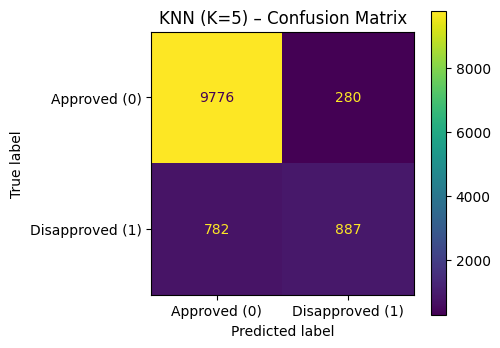

In [20]:
#Confusion matrix – KNN
print("Confusion Matrix for KNN (K=5):")
cm_knn = confusion_matrix(y_test, knn_pred)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['Approved (0)', 'Disapproved (1)'])
fig, ax = plt.subplots(figsize=(5, 4))
disp_knn.plot(ax=ax)
ax.set_title(f'KNN (K=5) – Confusion Matrix')
plt.tight_layout()
plt.show()

**Code Reuse Session 2 - Seminnar Session 4**


ROC Curve for KNN (K=5):


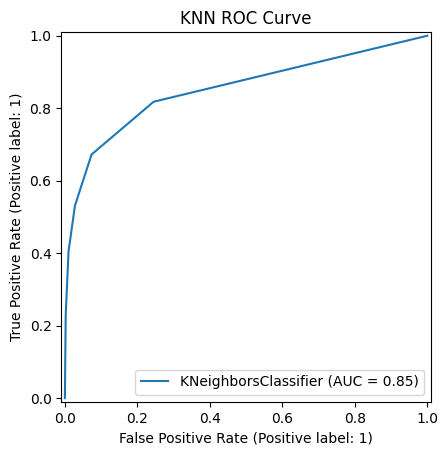

In [21]:
# Calculate probabilities and AUC for KNN
knn_prob = knn_model.predict_proba(X_test_scaled)[:, 1]
knn_auc = roc_auc_score(y_test, knn_prob)

#AUC-ROC curve – KNN
print("\nROC Curve for KNN (K=5):")

# Plot ROC curve using RocCurveDisplay
RocCurveDisplay.from_estimator(knn_model, X_test_scaled, y_test)
plt.title('KNN ROC Curve')
plt.show()

## Task (5b) – All Test Scores for All Models

In [22]:
#Calculate all 5 matrics for each model
results = {
    'NB':          {'pred': naive_bayes_pred,  'prob': nb_prob},
    'LR':          {'pred': lr_pred,  'prob': lr_prob},
    f'KNN(5)': {'pred': knn_pred, 'prob': knn_prob},
}

#checked how well model detect desapproved loans (pos_label=1)
#rounded up to 4 decimal places
rows = []
for name, vals in results.items():
    rows.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score (y_test, vals['pred']), 4), #accuracy of the model
        'Recall':    round(recall_score   (y_test, vals['pred'], pos_label=1), 4), #how many positives were actually found
        'Precision': round(precision_score(y_test, vals['pred'], pos_label=1), 4), #how many predicted positives were actually true positives
        'F1-Score':   round(f1_score       (y_test, vals['pred'], pos_label=1), 4), #balance in precision and recall
        'AUC-ROC':   round(roc_auc_score  (y_test, vals['prob']), 4), #how well the model seperate two classes
    })

metrics_df = pd.DataFrame(rows).set_index('Model')
print("...Test scores for 3 models (fo rejected)...")
print(metrics_df)


...Test scores for 3 models (fo rejected)...
        Accuracy  Recall  Precision  F1-Score  AUC-ROC
Model                                                 
NB        0.8426  0.5986     0.4595    0.5199   0.8476
LR        0.8888  0.3883     0.6960    0.4985   0.8640
KNN(5)    0.9094  0.5315     0.7601    0.6255   0.8526


##Task (5c) - Best Model Selection

**Model Selection Justification**

The goal was to maximise "Reject" predictions while ensuring they are correctly identified.

Since the model needs to have both **high recall** and **high precision**, the **F1-score** was chosen as the best metric for evaluation.

**Naive Bayes — Not Selected**

- has a high recall but low precision
F1-score (0.5199), moderate balance

**Logistic Regression — Not Selected**

- has the highest recall but the lowest precision
also has the lowest F1-score (0.4985)

**KNN (K=5) — Selected**

- recall is lower compared to the other models
but has the highest precision and F1-score

**Final Model Selection**

- KNN (K=5) is selected as the best model since it provides the best balance between detecting rejected applications and ensuring those predictions are correct.


## Task (5d) – Hyperparameter Tuning with GridSearchCV

**Code Reuse Session 2 - Seminnar Session 4**

In [23]:
# Hyperparameter grid for KNN
param_grid_knn = {
    'n_neighbors': np.arange(1, 25),
    'metric': ['euclidean', 'manhattan'],
    'weights': ['uniform', 'distance']
}

# GridSearchCV for KNN
grid_search_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',  # Refit the best f1-score model
    n_jobs=-1 # Use all available CPU cores
)
grid_search_knn.fit(X_train_scaled, y_train)

# Check top performing parameters
print("Best Hyperparameters found by GridSearchCV:")
print(grid_search_knn.best_params_)

Best Hyperparameters found by GridSearchCV:
{'metric': 'manhattan', 'n_neighbors': np.int64(8), 'weights': 'distance'}


**Code Reuse Session 2 - Seminnar Session 4**

In [27]:
# re-evaluate the tuned KNN model
knn_tuned_model = grid_search_knn.best_estimator_
knn_tuned_pred   = knn_tuned_model.predict(X_test_scaled)
knn_tuned_prob  = knn_tuned_model.predict_proba(X_test_scaled)[:, 1]
knn_tuned_auc   = roc_auc_score(y_test, knn_tuned_prob)

print("Classification report for KNN (Tuned):\n")
print(classification_report(y_test, knn_tuned_pred, target_names=['Approved (0)', 'Disapproved (1)']))

Classification report for KNN (Tuned):

                 precision    recall  f1-score   support

   Approved (0)       0.93      0.98      0.95     10056
Disapproved (1)       0.81      0.52      0.64      1669

       accuracy                           0.92     11725
      macro avg       0.87      0.75      0.79     11725
   weighted avg       0.91      0.92      0.91     11725

Classification report for KNN (Tuned):

                 precision    recall  f1-score   support

   Approved (0)       0.93      0.98      0.95     10056
Disapproved (1)       0.81      0.52      0.64      1669

       accuracy                           0.92     11725
      macro avg       0.87      0.75      0.79     11725
   weighted avg       0.91      0.92      0.91     11725



**Code Reuse Session 2 - Seminnar Session 4**

Confusion Matrix for KNN Before Tuning:


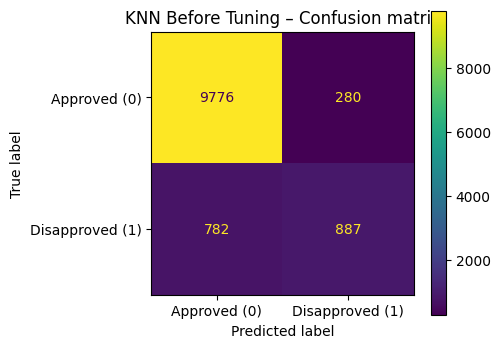

Confusion Matrix for KNN After Tuning:


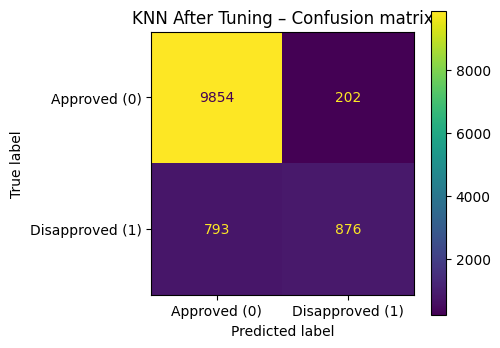

In [28]:
#Confusion matrix before tuning
print("Confusion Matrix for KNN Before Tuning:")
cm_knn_before = confusion_matrix(y_test, knn_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn_before, display_labels=['Approved (0)', 'Disapproved (1)'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax)
ax.set_title('KNN Before Tuning – Confusion matrix')
plt.tight_layout()
plt.show()


#Confusion matrix after tuning
print("Confusion Matrix for KNN After Tuning:")
cm_knn_after = confusion_matrix(y_test, knn_tuned_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn_after, display_labels=['Approved (0)', 'Disapproved (1)'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax)
ax.set_title('KNN After Tuning – Confusion matrix')
plt.tight_layout()
plt.show()

In [29]:
#Comparing metrics scores before and after tuning
#since we need to find rejected application pos_label = 1 is used.
comparison = pd.DataFrame({
    'Metric': ['Recall', 'Precision', 'F-Score', 'AUC-ROC'],
    'Before Tuning': [
        round(recall_score (y_test, knn_pred, pos_label=1), 4),
        round(precision_score (y_test, knn_pred, pos_label=1), 4),
        round(f1_score (y_test, knn_pred, pos_label=1), 4),
        round(knn_auc, 4),
    ],
    'After Tuning': [
        round(recall_score (y_test, knn_tuned_pred, pos_label=1), 4),
        round(precision_score (y_test, knn_tuned_pred, pos_label=1), 4),
        round(f1_score (y_test, knn_tuned_pred, pos_label=1), 4),
        round(knn_tuned_auc,  4),
    ],
}).set_index('Metric')

print("KNN performance before and after hyperparameter tuning")
print(comparison)

KNN performance before and after hyperparameter tuning
           Before Tuning  After Tuning
Metric                                
Recall            0.5315        0.5249
Precision         0.7601        0.8126
F-Score           0.6255        0.6378
AUC-ROC           0.8526        0.8717
